In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy
import os
import time
import euclidlib as el

# Euclid imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint

/Users/s2265800/miniforge3/envs/mgl_ccl_cloe_env/lib/python3.11/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...


Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


In [2]:
# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

In [3]:
import sys
import os
sys.path.append('../../MGlensing')
import MGLensing


Bacco not installed!
PyHMCode not installed!
eMANTIS not installed!
PyHMCode not installed!
nDGPemu not installed!
/Users/s2265800/Desktop/GitHub/playground_th1/validation/../../MGlensing/MGLensing


In [4]:
MGL = MGLensing.MGL("/Users/s2265800/Desktop/GitHub/MGlensing/config_cloe_comparison.yaml")

model["nl_model"] =  0
initialising hmcode
################################
checking parameters for data....
all good with the data dictionary
################################
start computing mock data
computing data vector
wl_masked_ells:  567
gc_masked_ells:  483
xc_masked_ells:  828
3x2pt_masked_ells:  1878
computing data covariance


cov_flat:  (2496, 2496)
cov_flat_masked:  (1878, 1878)
managed to do cholesky decomposition
######CHOLESKY!!!!########
finish computing mock data
################################
model["nl_model"] =  0
initialising hmcode


################################
checking parameters for theory....
all good with the model parameters
################################


In [5]:
zz = MGL.Survey.zz_integr
nbin = MGL.Survey.nbin_s


l_wl_max, l_gc_max = MGL.Survey.ells_wl_max, MGL.Survey.ells_gc_max
l_wl, l_gc, l_xc = MGL.Survey.l_wl, MGL.Survey.l_gc, MGL.Survey.l_xc

In [6]:
z_nz, nz_heracles = el.photo.redshift_distributions('../tutorials/th1-kp4/nz_example.fits')
# Normalize and resample n(z) for both position and shear
def normalize_and_resample(nz_dict, z_grid, z_target):
    nz_array = np.vstack([nz / integrate.trapezoid(nz, z_grid) for nz in nz_dict.values()])
    return np.array([np.interp(z_target, z_grid, nz) for nz in nz_array])

my_dndz_pos_norm = normalize_and_resample(nz_heracles, z_nz, zz)
my_dndz_she_norm = normalize_and_resample(nz_heracles, z_nz, zz)

In [7]:
# cells_data['SHE', 'SHE', 6, 6].shape (2, 32) (E-mode and B-mode)
# cells_data['POS', 'POS', 6, 6].shape (32)
# cells_data['POS', 'SHE', 6, 6].shape (2, 32)
cells_data = el.photo.angular_power_spectra('../tutorials/th1-kp4/synth_cells_5000_binned.fits')

ells = cells_data[('SHE', 'SHE', 1, 1)].ell
nl = len(ells)
ells

array([  11.5,   13.5,   16. ,   19.5,   24. ,   29.5,   35.5,   43. ,
         52.5,   63.5,   77. ,   93.5,  113.5,  138. ,  168. ,  204. ,
        247.5,  300.5,  365. ,  443.5,  538.5,  654. ,  794. ,  964. ,
       1171. , 1422. , 1726.5, 2096.5, 2546. , 3091.5, 3754. , 4558.5])

In [8]:
# These are the default parameters used to generate the synthetic data
default_pars = {'H0':67,'Omega_cdm0':0.27,'Omega_b0':0.049,'ns':0.96,'As':2.1e-9,
                'w0':-1,'wa':0, 'Omega_k0':0,'mnu':0.0,'gamma_MG':0.545,
                'log10TAGN': None, #7.75,
                'AIA':0.16, 'EtaIA':1.66,'CIA': 0.0134, 
                #'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414,
                #'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913,
                'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
                'dz_pos_1': 0.0, 'dz_pos_2': 0.0,
                'dz_pos_3': 0.0, 'dz_pos_4': 0.0,
                'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
                'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
                'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
                'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
                'dz_shear_1': 0.0, 'dz_shear_2': 0.0,
                'dz_shear_3': 0.0, 'dz_shear_4': 0.0,
                'dz_shear_5': 0.0, 'dz_shear_6': 0.0}
# The arguments of the Background functions follow the cosmology.API
background = CAMBBackground(H0=default_pars['H0'], 
                            Omega_cdm0=default_pars['Omega_cdm0'], 
                            Omega_b0=default_pars['Omega_b0'], 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = default_pars['ns'], 
                            As = default_pars['As'],
                            mnu = 0.0,
                            gamma_MG = default_pars['gamma_MG'])
linear_perturbations_emu = HMemuLinearPerturbations(background, zz)
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(background, linear_perturbations_emu, zz, log10TAGN=default_pars['log10TAGN'])       

# Select the perturbations object you want to use
perturbations = nonlinear_perturbations_emu

# Define the tracers
tracer_she = ShearTracer(perturbations=perturbations, 
                             dndz=my_dndz_she_norm,
                             z = zz,
                             nuisance_params=default_pars)
tracer_pos_cloe = PositionsTracer(perturbations=perturbations, 
                            dndz=my_dndz_pos_norm,
                            z=zz,
                            galaxy_bias_model='per_bin',
                            nuisance_params={ 'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                                              'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                                              'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
                                              'dz_pos_1': 0.000, 'dz_pos_2': 0.000,
                                              'dz_pos_3': 0.000, 'dz_pos_4': 0.000,
                                              'dz_pos_5': 0.000, 'dz_pos_6': 0.000}

                            )

In [9]:
twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)
cells_EE = twopoint_sheshe.get_Cl(ells, 0, perturbations.k)

twopoint_pospos = AngularTwoPoint(tracer_pos_cloe, tracer_pos_cloe)
cells_GG = twopoint_pospos.get_Cl(ells, 0, perturbations.k)

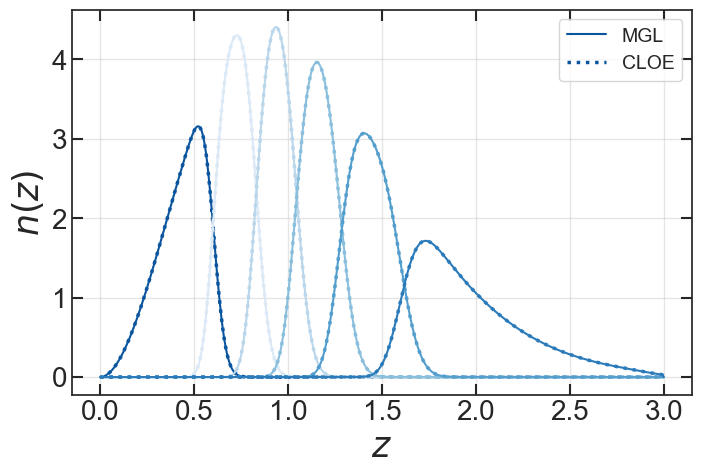

In [10]:
fig, axs = plt.subplots(1, 1, figsize=(8,5))

axs.set_ylabel(r'$n(z)$', fontsize=25)
axs.set_xlabel(r'$z$', fontsize=25)

for i in range(6):
    if i==0:
        axs.plot(zz, MGL.Survey.eta_z_s.T[i,:], linewidth=1.5, ls='-', color=sns.color_palette("Blues", 6)[i-1], label = r'MGL')
        axs.plot(zz, my_dndz_she_norm[i,:], linewidth=2.5, ls=':', color=sns.color_palette("Blues", 6)[i-1], label = r'CLOE')

    else:
        axs.plot(zz, MGL.Survey.eta_z_s.T[i,:], linewidth=1.5, ls='-', color=sns.color_palette("Blues", 6)[i-1])
        axs.plot(zz, my_dndz_she_norm[i,:], linewidth=2.5, ls=':', color=sns.color_palette("Blues", 6)[i-1])


axs.tick_params(direction='in', which='major', length=8, width=1.5, top=True, right=True)
axs.tick_params(direction='in', which='minor', length=4, width=1.5, top=True, right=True)
axs.grid(alpha=0.5)

axs.legend()

In [11]:
params = {
    'Omega_m' :  default_pars['Omega_cdm0']+default_pars['Omega_b0'],
    'Omega_c' :  default_pars['Omega_cdm0'],
    'Omega_cb' :  default_pars['Omega_cdm0'],
    'Omega_nu':  0.,
    'As'      :  default_pars['As'],
    'Omega_b' :  default_pars['Omega_b0'],
    'ns'      :  default_pars['ns'],
    'h'       :  default_pars['H0']/100,
    'Mnu'     :  0.0,
    'w0'      :  -1.0,
    'wa'      :  0.0,
    'a1_IA': default_pars['AIA'],
    'eta1_IA': default_pars['EtaIA'],
    'beta_IA': 0.,
}
b0 = 1.
for bin_i in range(nbin):
    params[f'b1_{bin_i+1}']=b0

model_opt = {'nl_model': 0, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.}
cl_ll_mgl_hm, cl_gg_mgl_hm, _, _ =  MGL.get_c_ells(params, model_opt)

model["nl_model"] =  0
initialising hmcode
Theo model:  {'nl_model': 0, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}


In [12]:
W_WL, W_IA, W_GC = MGL.get_windows(params, model_opt)

model["nl_model"] =  0
initialising hmcode


Theo model:  {'nl_model': 0, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}


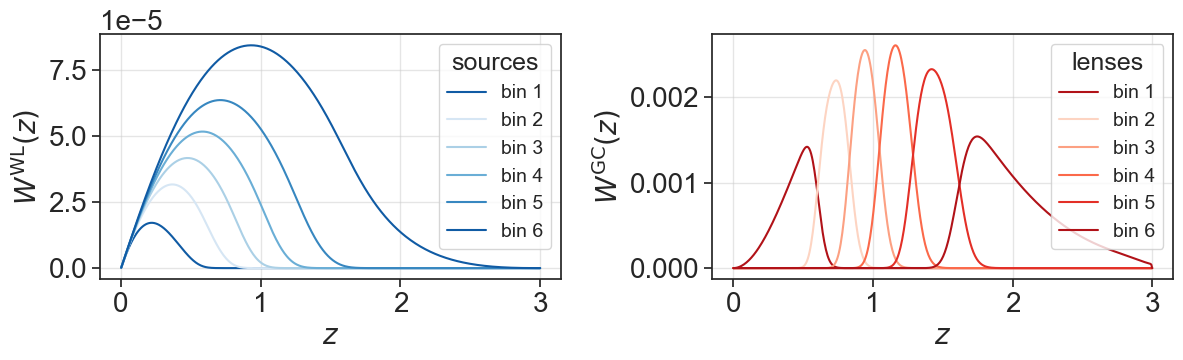

In [27]:
titles = ['sources', 'lenses']
etaz = [MGL.Survey.eta_z_s, MGL.Survey.eta_z_l]
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for k in range(2):
    for i in range(etaz[k].shape[1]):
        if k==0:
            ax[k].plot(zz, W_WL[0, :, i], label='bin ' + str(i + 1), color=sns.color_palette("Blues", 5)[i-1],linewidth=1.5)
        else:
            ax[k].plot(zz, W_GC[0 ,:, i], label='bin ' + str(i + 1), color=sns.color_palette("Reds", 5)[i-1],linewidth=1.5)
    ax[k].set_xlabel("$z$")
    ax[k].grid(alpha=0.5)
    ax[k].legend(loc='upper right', title=titles[k], title_fontsize=18)
ax[0].set_ylabel("$W^{\\rm WL}(z)$")
ax[1].set_ylabel("$W^{\\rm GC}(z)$")
plt.tight_layout()

In [13]:
prefactor_wl = \
            (np.sqrt((l_wl + 2.0) * (l_wl + 1.0) * l_wl * (l_wl - 1.0)) /
             (l_wl + 0.5) ** 2)

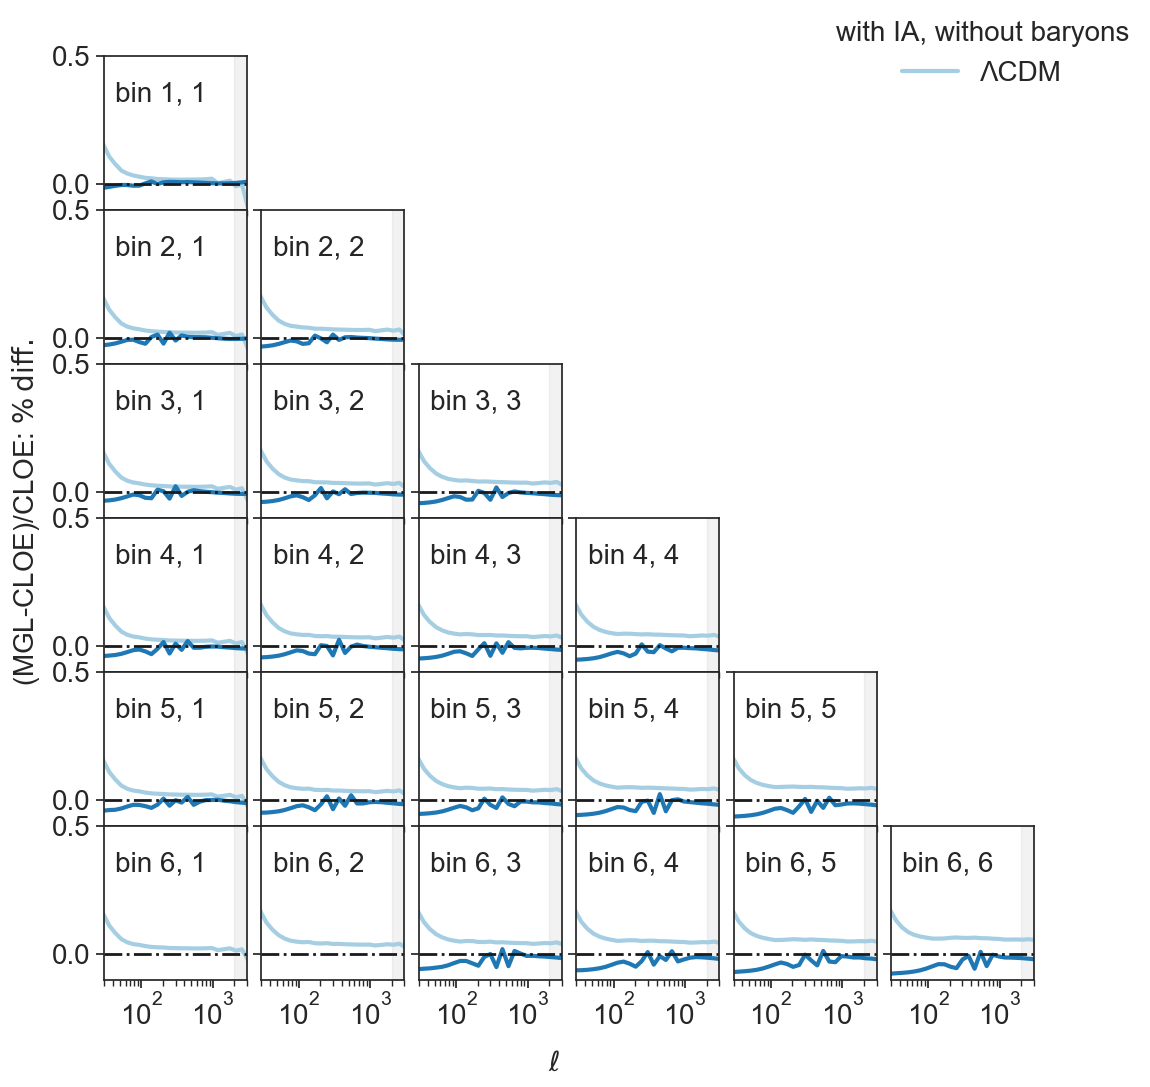

In [14]:
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            ax[i,j].semilogx(l_wl, (prefactor_wl*cl_ll_mgl_hm[:,i,j]-cells_EE[:,i,j])/cells_EE[:,i,j]*100)
            ax[i,j].semilogx(l_gc, (cl_gg_mgl_hm[:,i,j]-cells_GG[:,i,j])/cells_GG[:,i,j]*100)
            #ax[i, j].set_ylim(0.987, 1.013)
            ax[i, j].set_ylim(-0.1, 0.5)
            ax[i, j].set_xlim(30, 3000)
            ax[i,j].text(.4, .7, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes) # if i<2 else ax[i,j].text(.4, .2, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            ax[i, j].axhline(y=0, linestyle='-.', linewidth=2, color='k')
            ax[i, j].axvspan(xmin=l_wl_max[i, j], xmax=l_wl[-1], color='grey', alpha=0.1)
        else:
            ax[i,j].axis('off')       
#fig.text(0.03, 0.5, r'$C^{\rm shear}_\ell/C^{\rm shear}_\ell$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.06, 0.5, r'(MGL-CLOE)/CLOE: $\% \: \rm{diff.}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)   
fig.legend([ 'ΛCDM'], title='with IA, without baryons', loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)

In [15]:
mu0_arr = [0., -0.7, 1.5]
sigma0_arr = [0., -0.5, 1.7]
q1_arr = [0., 0., 0.]

In [16]:
cl_mgl_lin = []
cl_mgl_nonlin = []
cl_mgl_lin_gg = []
cl_mgl_nonlin_gg = []
for i in range(len(mu0_arr)):
    model_opt = {'nl_model': 4, 'option':'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.}
    params['mu0'] = mu0_arr[i]
    params['sigma0'] = sigma0_arr[i]
    params['q1'] = q1_arr[i]
    cl_ll_mgl, cl_gg_mgl, _, _ =  MGL.get_c_ells(params, model_opt)
    cl_mgl_lin.append(cl_ll_mgl)
    cl_mgl_lin_gg.append(cl_gg_mgl)
    model_opt = {'nl_model': 4, 'option':None, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.}
    cl_ll_mgl, cl_gg_mgl, _, _ =  MGL.get_c_ells(params, model_opt)
    cl_mgl_nonlin.append(cl_ll_mgl)
    cl_mgl_nonlin_gg.append(cl_gg_mgl)

model["nl_model"] =  4
initialising mu-Sigma
Theo model:  {'nl_model': 4, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
model["nl_model"] =  4
initialising mu-Sigma


Theo model:  {'nl_model': 4, 'option': None, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
model["nl_model"] =  4
initialising mu-Sigma


Theo model:  {'nl_model': 4, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
model["nl_model"] =  4
initialising mu-Sigma


Theo model:  {'nl_model': 4, 'option': None, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
model["nl_model"] =  4
initialising mu-Sigma


Theo model:  {'nl_model': 4, 'option': 'linear', 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}
model["nl_model"] =  4
initialising mu-Sigma


Theo model:  {'nl_model': 4, 'option': None, 'bias_model': 0, 'ia_model': 0, 'baryon_model': 0, 'photoz_err_model': 0.0}


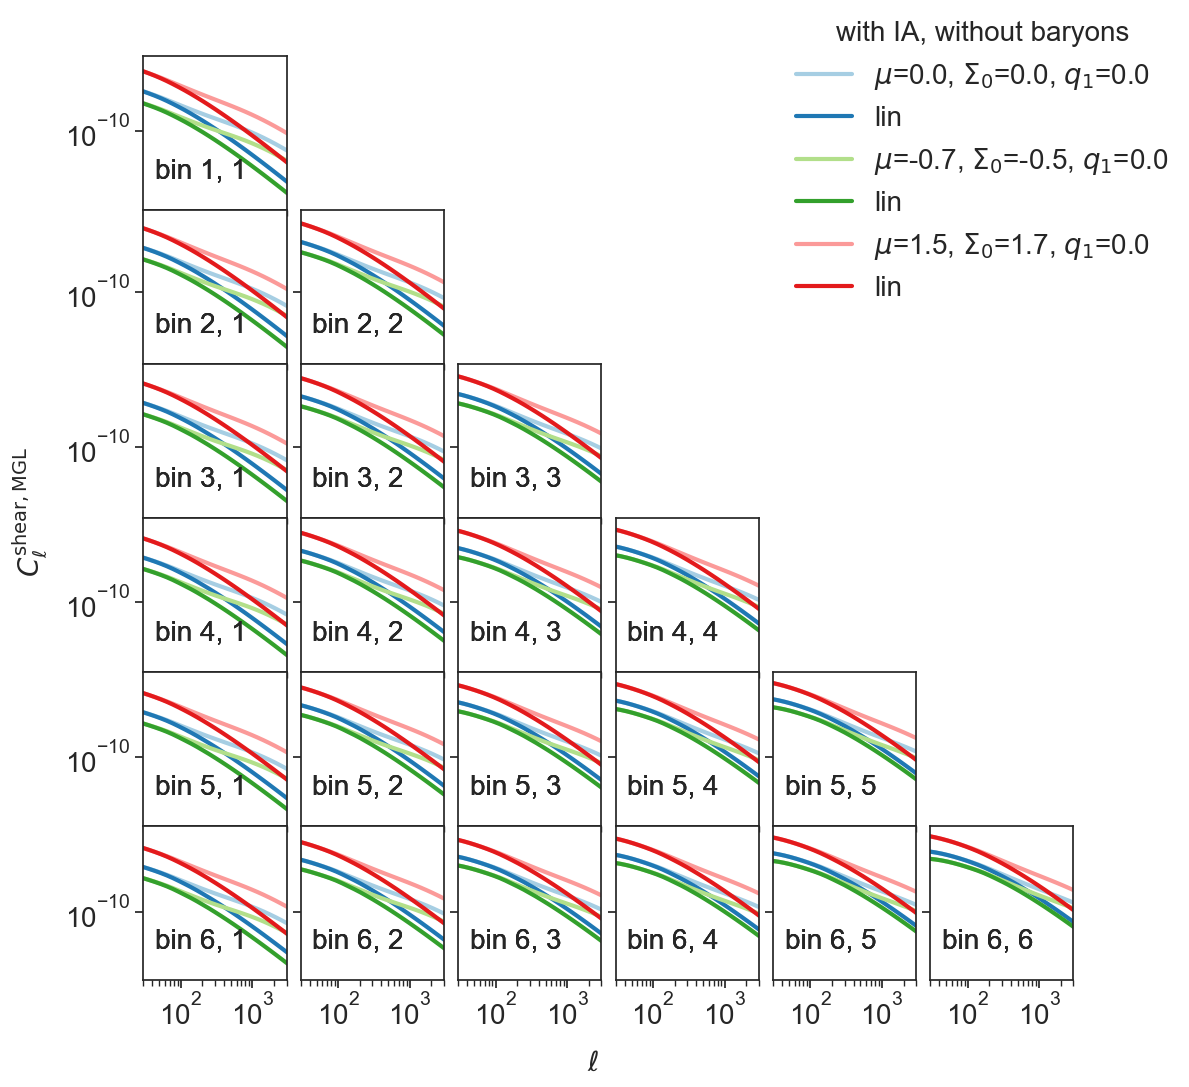

In [17]:
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for num in range(len(mu0_arr)):
    for i in range(nbin):
        for j in range(nbin):
            if i >= j:
                ax[i,j].loglog(l_wl, cl_mgl_nonlin[num][:, i, j])
                ax[i,j].loglog(l_wl, cl_mgl_lin[num][:, i, j])
                ax[i, j].set_xlim(30, 3000)
                ax[i,j].text(.4, .2, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes) 
            else:
                ax[i,j].axis('off')       
fig.text(0.03, 0.5, r'$C^{\rm shear, MGL}_\ell$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)   
fig.legend([f'$\mu$={mu0_arr[0]}, $\Sigma_0$={sigma0_arr[0]}, $q_1$={q1_arr[0]}', 'lin', f'$\mu$={mu0_arr[1]}, $\Sigma_0$={sigma0_arr[1]}, $q_1$={q1_arr[1]}', 'lin', f'$\mu$={mu0_arr[2]}, $\Sigma_0$={sigma0_arr[2]}, $q_1$={q1_arr[2]}', 'lin'], title='with IA, without baryons', loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)

In [18]:
from cloelib.cosmology.mgrowth_cosmology import MGrowthLinearPerturbations
from cloelib.cosmology.reactemu_cosmology import MGemuNonlinearBoost, BoostedPerturbations

/Users/s2265800/miniforge3/envs/mgl_ccl_cloe_env/lib/python3.11/site-packages/MGEmu


In [19]:

cl_cloe_lin = []
cl_cloe_nonlin = []
cl_cloe_lin_gg = []
cl_cloe_nonlin_gg = []
for i in range(len(mu0_arr)):
    mgpars = {
    'mu0': mu0_arr[i],
    'sigma0': sigma0_arr[i],
    'q1': q1_arr[i]
    }
    MGrowth_perturbations = MGrowthLinearPerturbations(background, linear_perturbations_emu,
                                                     gravity_model='musigma-de',
                                                     mgpars=mgpars)
    perturbations = MGrowth_perturbations
    # Define the tracers
    tracer_she = ShearTracer(perturbations=perturbations, 
                                dndz=my_dndz_she_norm,
                                z = zz,
                                nuisance_params=default_pars)
    twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)
    cells_EE = twopoint_sheshe.get_Cl(ells, 0, perturbations.k)
    cl_cloe_lin.append(cells_EE)

    tracer_pos_cloe = PositionsTracer(perturbations=perturbations, 
                            dndz=my_dndz_pos_norm,
                            z=zz,
                            galaxy_bias_model='per_bin',
                            nuisance_params={ 'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                                              'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                                              'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
                                              'dz_pos_1': 0.000, 'dz_pos_2': 0.000,
                                              'dz_pos_3': 0.000, 'dz_pos_4': 0.000,
                                              'dz_pos_5': 0.000, 'dz_pos_6': 0.000}

                            )
    twopoint_pospos = AngularTwoPoint(tracer_pos_cloe, tracer_pos_cloe)
    cells_pospos = twopoint_pospos.get_Cl(ells, 0, perturbations.k)
    cl_cloe_lin_gg.append(cells_pospos)

   
                                                   
    boost = MGemuNonlinearBoost(background, linear_perturbations_emu, zz, gravity_model='musigma-de', mgpars=mgpars)
    perturbations = BoostedPerturbations(MGrowth_perturbations, nonlinear_perturbations_emu, boost.MGboost_interp)
    tracer_she = ShearTracer(perturbations=perturbations, 
                                dndz=my_dndz_she_norm,
                                z = zz,
                                nuisance_params=default_pars)
    twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)
    cells_EE = twopoint_sheshe.get_Cl(ells, 0, perturbations.k)
    cl_cloe_nonlin.append(cells_EE)
    tracer_pos_cloe = PositionsTracer(perturbations=perturbations, 
                            dndz=my_dndz_pos_norm,
                            z=zz,
                            galaxy_bias_model='per_bin',
                            nuisance_params={ 'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
                                              'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
                                              'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
                                              'dz_pos_1': 0.000, 'dz_pos_2': 0.000,
                                              'dz_pos_3': 0.000, 'dz_pos_4': 0.000,
                                              'dz_pos_5': 0.000, 'dz_pos_6': 0.000}

                            )
    twopoint_pospos = AngularTwoPoint(tracer_pos_cloe, tracer_pos_cloe)
    cells_pospos = twopoint_pospos.get_Cl(ells, 0, perturbations.k)
    cl_cloe_nonlin_gg.append(cells_pospos)

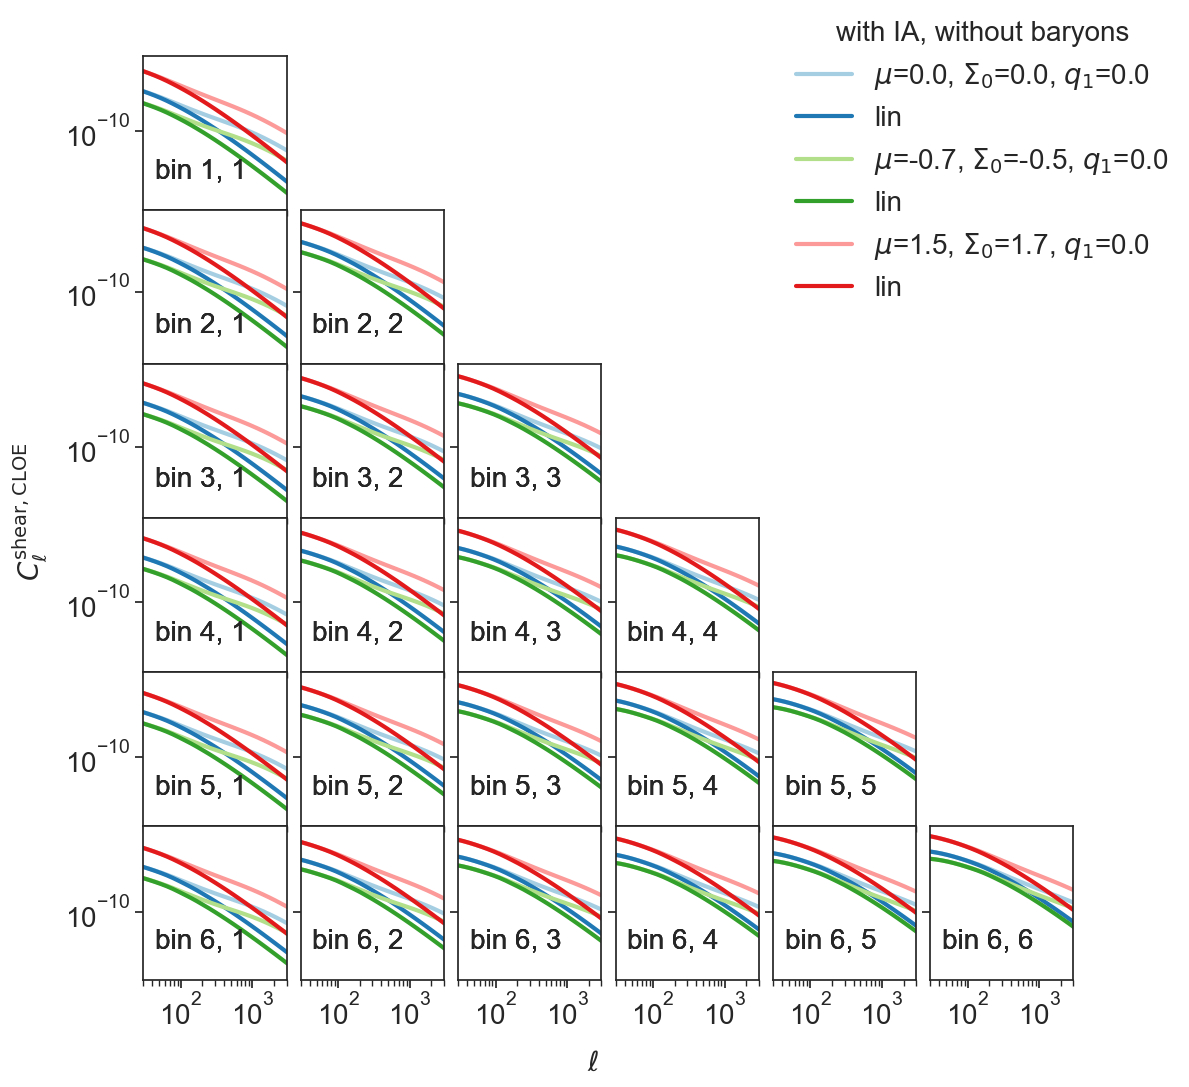

In [20]:
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for num in range(len(mu0_arr)):
    for i in range(nbin):
        for j in range(nbin):
            if i >= j:
                ax[i,j].loglog(l_wl, cl_cloe_nonlin[num][:, i, j])
                ax[i,j].loglog(l_wl, cl_cloe_lin[num][:, i, j])
                ax[i, j].set_xlim(30, 3000)
                ax[i,j].text(.4, .2, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes) 
            else:
                ax[i,j].axis('off')       
fig.text(0.03, 0.5, r'$C^{\rm shear, CLOE}_\ell$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)   
fig.legend([f'$\mu$={mu0_arr[0]}, $\Sigma_0$={sigma0_arr[0]}, $q_1$={q1_arr[0]}', 'lin', f'$\mu$={mu0_arr[1]}, $\Sigma_0$={sigma0_arr[1]}, $q_1$={q1_arr[1]}', 'lin', f'$\mu$={mu0_arr[2]}, $\Sigma_0$={sigma0_arr[2]}, $q_1$={q1_arr[2]}', 'lin'], title='with IA, without baryons', loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)

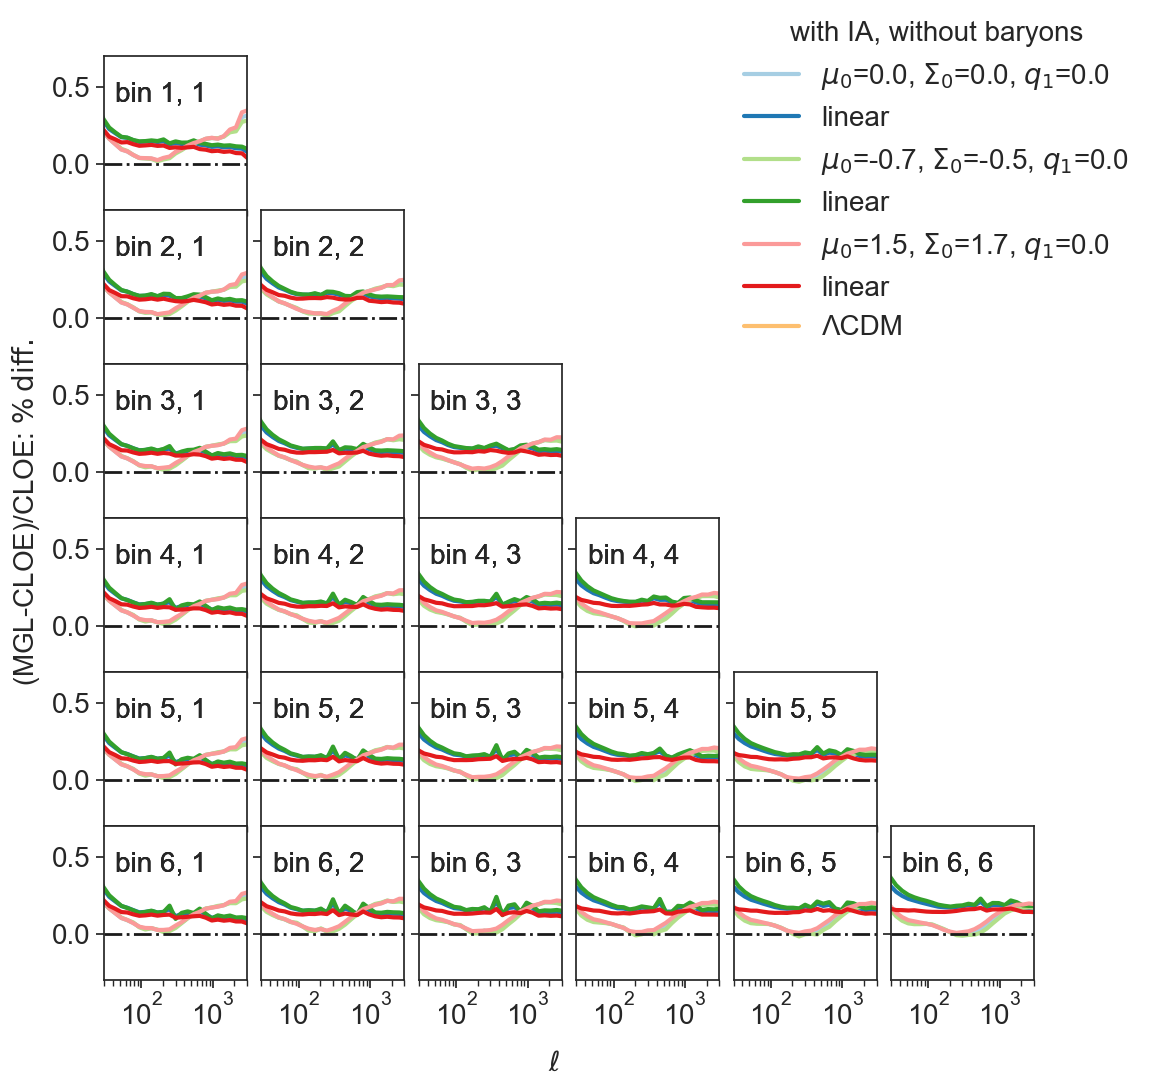

In [21]:
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for num in range(len(mu0_arr)):
    for i in range(nbin):
        for j in range(nbin):
            if i >= j:
                ax[i,j].semilogx(l_wl, (prefactor_wl*cl_mgl_nonlin[num][:,i,j]-cl_cloe_nonlin[num][:,i,j])/cl_cloe_nonlin[num][:,i,j]*100)
                ax[i,j].semilogx(l_wl, (prefactor_wl*cl_mgl_lin[num][:,i,j]-cl_cloe_lin[num][:,i,j])/cl_cloe_lin[num][:,i,j]*100)
                #ax[i, j].set_ylim(0.987, 1.013)
                ax[i, j].set_ylim(-0.3, 0.7)
                ax[i, j].set_xlim(30, 3000)
                ax[i,j].text(.4, .7, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes) # if i<2 else ax[i,j].text(.4, .2, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            else:
                ax[i,j].axis('off')
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            ax[i,j].semilogx(l_wl, (prefactor_wl*cl_ll_mgl_hm[:,i,j]-cells_EE[:,i,j])/cells_EE[:,i,j]*100)
            ax[i, j].axhline(y=0, linestyle='-.', linewidth=2, color='k') 
        else:
            ax[i,j].axis('off')                           
#fig.text(0.03, 0.5, r'$C^{\rm shear}_\ell/C^{\rm shear}_\ell$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.06, 0.5, r'(MGL-CLOE)/CLOE: $\% \: \rm{diff.}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)   
fig.legend([f'$\mu_0$={mu0_arr[0]}, $\Sigma_0$={sigma0_arr[0]}, $q_1$={q1_arr[0]}', 'linear', f'$\mu_0$={mu0_arr[1]}, $\Sigma_0$={sigma0_arr[1]}, $q_1$={q1_arr[1]}', 'linear', f'$\mu_0$={mu0_arr[2]}, $\Sigma_0$={sigma0_arr[2]}, $q_1$={q1_arr[2]}', 'linear', 'ΛCDM'], title='with IA, without baryons', loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)

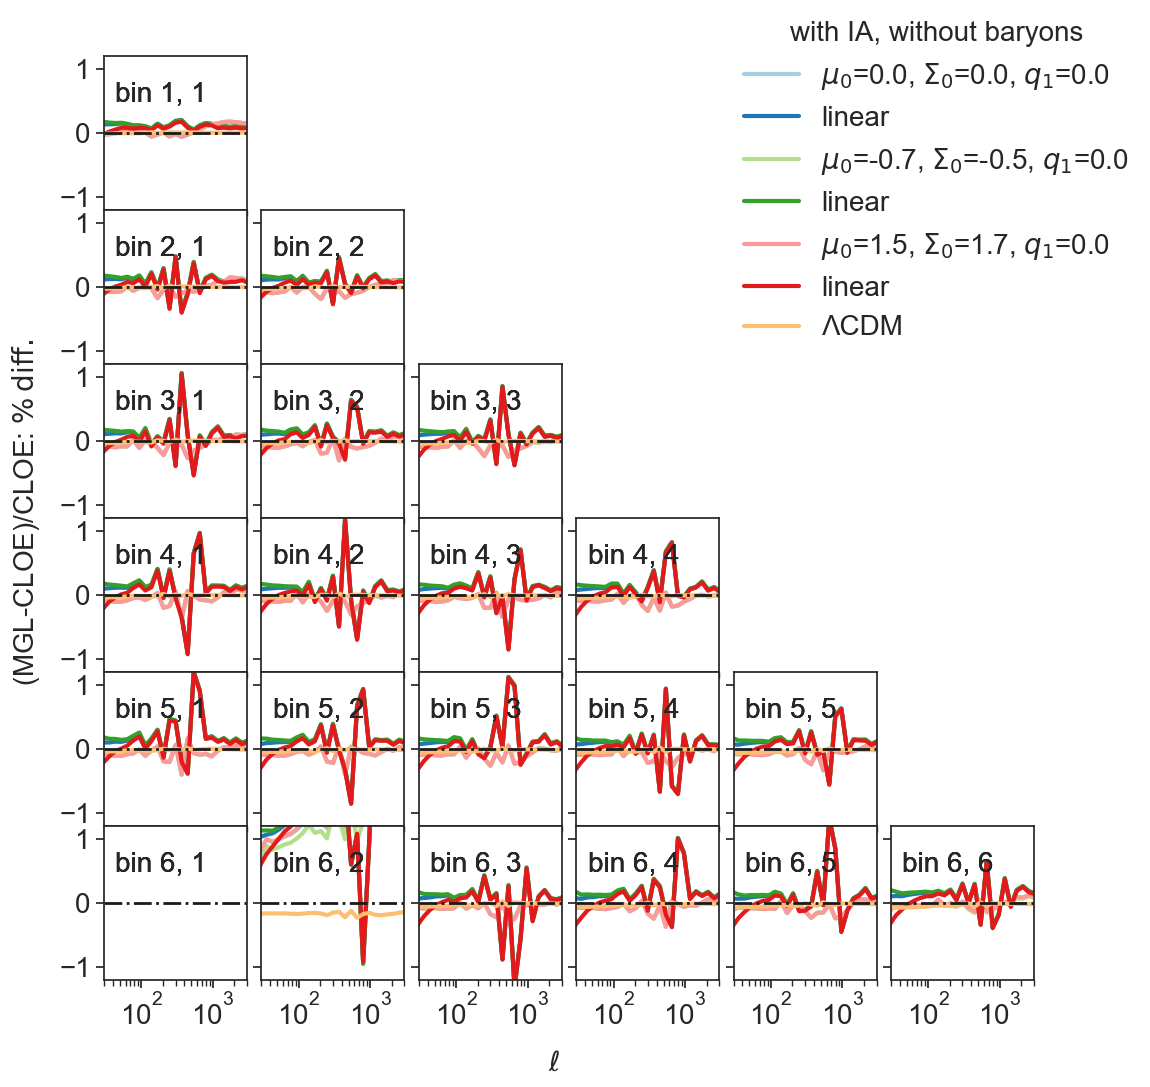

In [26]:
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for num in range(len(mu0_arr)):
    for i in range(nbin):
        for j in range(nbin):
            if i >= j:
                ax[i,j].semilogx(l_wl, (cl_mgl_nonlin_gg[num][:,i,j]-cl_cloe_nonlin_gg[num][:,i,j])/cl_cloe_nonlin_gg[num][:,i,j]*100)
                ax[i,j].semilogx(l_wl, (cl_mgl_lin_gg[num][:,i,j]-cl_cloe_lin_gg[num][:,i,j])/cl_cloe_lin_gg[num][:,i,j]*100)
                #ax[i, j].set_ylim(0.987, 1.013)
                ax[i, j].set_ylim(-1.2, 1.2)
                ax[i, j].set_xlim(30, 3000)
                ax[i,j].text(.4, .7, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes) # if i<2 else ax[i,j].text(.4, .2, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            else:
                ax[i,j].axis('off')
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            ax[i,j].semilogx(l_gc, (cl_gg_mgl_hm[:,i,j]-cells_GG[:,i,j])/cells_GG[:,i,j]*100)
            ax[i, j].axhline(y=0, linestyle='-.', linewidth=2, color='k') 
        else:
            ax[i,j].axis('off')                           
#fig.text(0.03, 0.5, r'$C^{\rm shear}_\ell/C^{\rm shear}_\ell$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.06, 0.5, r'(MGL-CLOE)/CLOE: $\% \: \rm{diff.}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'$\ell$', ha='center', va='center', fontsize=20)   
fig.legend([f'$\mu_0$={mu0_arr[0]}, $\Sigma_0$={sigma0_arr[0]}, $q_1$={q1_arr[0]}', 'linear', f'$\mu_0$={mu0_arr[1]}, $\Sigma_0$={sigma0_arr[1]}, $q_1$={q1_arr[1]}', 'linear', f'$\mu_0$={mu0_arr[2]}, $\Sigma_0$={sigma0_arr[2]}, $q_1$={q1_arr[2]}', 'linear', 'ΛCDM'], title='with IA, without baryons', loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)